### Setup and Configuration 

In [ ]:


import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import segmentation_models_pytorch as smp
import numpy as np
import os
import pandas as pd
import cv2
import time
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

#Albumentations Imports 
import albumentations as A
from albumentations.pytorch import ToTensorV2

print("--- Setting up for Cityscapes Dataset and SegNet Training ---")

#GLOBAL CONFIGURATION 
IMG_HEIGHT = 256
IMG_WIDTH = 512 

NUM_CLASSES_CITYSCAPES = 19 
IGNORE_INDEX_CITYSCAPES = 255 

#PATHS 
CITYSCAPES_ROOT_DATA_DIR = '/home/5177/deep_vision'

TRAIN_IMAGE_DIR = os.path.join(CITYSCAPES_ROOT_DATA_DIR, 'leftImg8bit_trainvaltest', 'leftImg8bit', 'train')
TRAIN_MASK_DIR = os.path.join(CITYSCAPES_ROOT_DATA_DIR, 'gtFine_trainvaltest', 'gtFine', 'train')
VAL_IMAGE_DIR = os.path.join(CITYSCAPES_ROOT_DATA_DIR, 'leftImg8bit_trainvaltest', 'leftImg8bit', 'val')
VAL_MASK_DIR = os.path.join(CITYSCAPES_ROOT_DATA_DIR, 'gtFine_trainvaltest', 'gtFine', 'val')

# Directories for saving models, plots, and experiment results
SAVE_MODELS_DIR = "./saved_models_cityscapes"
SAVE_PLOTS_DIR = "./saved_plots_cityscapes"
SAVE_CSV_DIR = "./experiment_results_cityscapes"

os.makedirs(SAVE_MODELS_DIR, exist_ok=True)
os.makedirs(SAVE_PLOTS_DIR, exist_ok=True)
os.makedirs(SAVE_CSV_DIR, exist_ok=True)

#DEVICE CONFIGURATION 
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

# ISIC specific global parameters (needed if any ISIC-related functions are called, though not directly for Cityscapes train)
NUM_ISIC_CLASSES = 2

print("Configuration complete. Ready for Cityscapes Dataset definition.")

--- Setting up for Cityscapes Dataset and SegNet Training ---
Using device: cuda
Configuration complete. Ready for Cityscapes Dataset definition.


### Cityscapes Dataset Class and Transforms

In [ ]:


import os
import torch
from torch.utils.data import Dataset
from PIL import Image
import numpy as np
import cv2

# Cityscapes Specifics 
CITYSCAPES_ID_TO_TRAINID = {
    -1: IGNORE_INDEX_CITYSCAPES, 0: IGNORE_INDEX_CITYSCAPES, 1: IGNORE_INDEX_CITYSCAPES,
    2: IGNORE_INDEX_CITYSCAPES, 3: IGNORE_INDEX_CITYSCAPES, 4: IGNORE_INDEX_CITYSCAPES,
    5: IGNORE_INDEX_CITYSCAPES, 6: IGNORE_INDEX_CITYSCAPES, 7: 0, 8: 1, 9: IGNORE_INDEX_CITYSCAPES,
    10: IGNORE_INDEX_CITYSCAPES, 11: 2, 12: 3, 13: 4, 14: IGNORE_INDEX_CITYSCAPES, 15: IGNORE_INDEX_CITYSCAPES,
    16: IGNORE_INDEX_CITYSCAPES, 17: 5, 18: IGNORE_INDEX_CITYSCAPES, 19: 6, 20: 7, 21: 8, 22: 9,
    23: 10, 24: 11, 25: 12, 26: 13, 27: 14, 28: 15, 29: IGNORE_INDEX_CITYSCAPES,
    30: IGNORE_INDEX_CITYSCAPES, 31: 16, 32: 17, 33: 18
}

# Cityscapes Dataset Class
class CityscapesDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.transform = transform
        
        self.image_paths = []
        self.mask_paths = []

        for city in os.listdir(images_dir):
            city_img_dir = os.path.join(images_dir, city)
            city_mask_dir = os.path.join(masks_dir, city)
            
            if not os.path.isdir(city_img_dir) or not os.path.isdir(city_mask_dir):
                continue

            for img_filename in os.listdir(city_img_dir):
                if img_filename.endswith('_leftImg8bit.png'):
                    img_path = os.path.join(city_img_dir, img_filename)
                    mask_filename = img_filename.replace('_leftImg8bit.png', '_gtFine_labelIds.png')
                    mask_path = os.path.join(city_mask_dir, mask_filename)

                    if os.path.exists(mask_path):
                        self.image_paths.append(img_path)
                        self.mask_paths.append(mask_path)
        
        print(f"Found {len(self.image_paths)} aligned image-mask pairs in {images_dir} and {masks_dir}")

        self.num_classes = NUM_CLASSES_CITYSCAPES
        self.ignore_index = IGNORE_INDEX_CITYSCAPES

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        remapped_mask = np.full_like(mask, self.ignore_index, dtype=np.uint8)
        for city_id, train_id in CITYSCAPES_ID_TO_TRAINID.items():
            remapped_mask[mask == city_id] = train_id

        if self.transform:
            augmented = self.transform(image=image, mask=remapped_mask)
            image = augmented['image']
            mask = augmented['mask']
            
            if mask.ndim == 3 and mask.shape[0] == 1:
                mask = mask.squeeze(0)
            mask = mask.long()

            return image, mask
        else:
            return image, remapped_mask

print("Cityscapes Dataset class defined.")

# Albumentations Transforms for Cityscapes  
cityscapes_train_transform = A.Compose([
    A.Resize(IMG_HEIGHT, IMG_WIDTH),
    
    # Geometric Augmentations
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=15, p=0.75, border_mode=cv2.BORDER_REFLECT_101),
    A.OpticalDistortion(distort_limit=0.05, shift_limit=0.05, p=0.5),
    A.GridDistortion(p=0.5),
    
    
   
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.GaussNoise(p=0.2),
    A.CLAHE(p=0.2),

   
    A.CoarseDropout(max_holes=8, max_height=32, max_width=32, fill_value=0, p=0.5),

    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

cityscapes_val_transform = A.Compose([
    A.Resize(IMG_HEIGHT, IMG_WIDTH),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# Define ISIC transforms also, for completeness, as get_dataloaders expects them
isic_train_strong_augment = A.Compose([
    A.Resize(256, 256), A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), ToTensorV2(),
])
isic_val_transform = A.Compose([
    A.Resize(256, 256), A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), ToTensorV2(),
])

print("Albumentations transforms for Cityscapes defined (ENHANCED).")

Cityscapes Dataset class defined.
Albumentations transforms for Cityscapes defined (ENHANCED).


/tmp/ipykernel_1740712/1718717854.py:91: UserWarning: Argument(s) 'shift_limit' are not valid for transform OpticalDistortion
  A.OpticalDistortion(distort_limit=0.05, shift_limit=0.05, p=0.5),
/tmp/ipykernel_1740712/1718717854.py:102: UserWarning: Argument(s) 'max_holes, max_height, max_width, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=32, max_width=32, fill_value=0, p=0.5), # Simulates occlusions


### Metrics, Plotting, Class Weights, Data Loaders

In [ ]:
import torch.optim as optim
import segmentation_models_pytorch as smp
from tqdm.notebook import tqdm
import torch.nn.functional as F
import matplotlib.pyplot as plt
import time 

print("

# 
def calculate_metrics(preds, targets, num_classes, ignore_index=None):
    preds_classes = preds.argmax(1) 

    if ignore_index is not None and ignore_index != -1:
        valid_pixels = (targets != ignore_index)
        preds_classes = preds_classes[valid_pixels]
        targets = targets[valid_pixels]
    
    if preds_classes.numel() == 0: 
        return 0.0, 0.0

    pixel_accuracy = (preds_classes == targets).sum().item() / targets.numel() if targets.numel() > 0 else 0.0

    iou_per_class = []
    for cl_idx in range(num_classes):
        if ignore_index is not None and cl_idx == ignore_index:
            continue 
        
        true_positive = ((preds_classes == cl_idx) & (targets == cl_idx)).sum().item()
        false_positive = ((preds_classes == cl_idx) & (targets != cl_idx)).sum().item()
        false_negative = ((preds_classes != cl_idx) & (targets == cl_idx)).sum().item()

        denominator = true_positive + false_positive + false_negative
        if denominator == 0:
            iou_per_class.append(np.nan)
        else:
            iou_per_class.append(true_positive / denominator)

    mean_iou = np.nanmean(iou_per_class) if iou_per_class else 0.0
    
    return pixel_accuracy, mean_iou


# Function to save plots 
def save_metrics_plot(train_losses, val_losses, train_accs, val_accs, train_mious, val_mious, filename_prefix):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs, val_losses, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, train_accs, label='Train Pixel Accuracy')
    plt.plot(epochs, val_accs, label='Validation Pixel Accuracy')
    plt.title('Training and Validation Pixel Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Pixel Accuracy')
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs, train_mious, label='Train mIoU')
    plt.plot(epochs, val_mious, label='Validation mIoU')
    plt.title('Training and Validation Mean IoU')
    plt.xlabel('Epoch')
    plt.ylabel('mIoU')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plot_path = os.path.join(SAVE_PLOTS_DIR, f"{filename_prefix}_metrics.png")
    plt.savefig(plot_path)
    plt.close()
    print(f"Metrics plot saved to {plot_path}")

# Function to calculate class weights 
def get_class_weights(dataset, num_classes, ignore_index, device):
    print(f"Calculating class weights for {dataset.__class__.__name__}...")
    class_pixel_counts = torch.zeros(num_classes, dtype=torch.long)
    total_valid_pixels = 0

    temp_loader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=2)

    # Correctly unpacks 2 values from __getitem__
    for _, masks in tqdm(temp_loader, desc="Counting pixels for class weights", leave=False):
        masks = masks.squeeze().flatten()
        valid_pixels_mask = (masks != ignore_index)
        valid_pixels_in_batch = masks[valid_pixels_mask]
        total_valid_pixels += valid_pixels_in_batch.numel()
        
        for c in range(num_classes):
            class_pixel_counts[c] += torch.sum(valid_pixels_in_batch == c).item()
    
    weights = torch.zeros(num_classes, dtype=torch.float)
    for c in range(num_classes):
        if class_pixel_counts[c] > 0:
            weights[c] = total_valid_pixels / (num_classes * class_pixel_counts[c])
        else:
            weights[c] = 1e-6
            print(f"Warning: Class {c} has zero pixels in the training set. Assigning a very small weight.")
    
    print(f"Calculated Class Weights: {weights.tolist()}")
    return weights.to(device)


# Function to get DataLoaders
def get_dataloaders(dataset_name, batch_size):
    if dataset_name == 'isic':
        print(f"Loading ISIC data...")
        # Note: ISICDataset and its transforms are placeholders if not used
        train_dataset = ISICDataset(images_dir=TRAIN_IMAGE_DIR, masks_dir=TRAIN_MASK_DIR, transform=isic_train_strong_augment)
        val_dataset = ISICDataset(images_dir=VAL_IMAGE_DIR, masks_dir=VAL_MASK_DIR, transform=isic_val_transform)
        num_classes = NUM_ISIC_CLASSES
        ignore_index = -1 
        class_weights = get_class_weights(train_dataset, num_classes, ignore_index, DEVICE)

    elif dataset_name == 'cityscapes':
        print(f"Loading Cityscapes data...")
        train_dataset = CityscapesDataset(images_dir=TRAIN_IMAGE_DIR, masks_dir=TRAIN_MASK_DIR, transform=cityscapes_train_transform)
        val_dataset = CityscapesDataset(images_dir=VAL_IMAGE_DIR, masks_dir=VAL_MASK_DIR, transform=cityscapes_val_transform)
        num_classes = NUM_CLASSES_CITYSCAPES
        ignore_index = IGNORE_INDEX_CITYSCAPES
        class_weights = get_class_weights(train_dataset, num_classes, ignore_index, DEVICE)

    else:
        raise ValueError(f"Unknown dataset: {dataset_name}. Choose 'isic' or 'cityscapes'.")

    train_loader = DataLoader(train_dataset, batch_size=batch_size, num_workers=2, pin_memory=True, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, num_workers=2, pin_memory=True, shuffle=False)

    print(f"DataLoaders created for {dataset_name}. Train: {len(train_dataset)} samples, Val: {len(val_dataset)} samples.")
    return train_loader, val_loader, num_classes, ignore_index, class_weights

# Function to create models 
def get_model(architecture, encoder_name, in_channels, num_classes):
    model = None
    if architecture.lower() == 'unet':
        # This option is not used in the SegNet-focused experiments, but kept for completeness
        model = smp.Unet(encoder_name=encoder_name, encoder_weights="imagenet", in_channels=in_channels, classes=num_classes)
        print(f"WARNING: You are trying to use smp.Unet. For SegNet project, ensure 'architecture' is 'segnet'.")
    elif architecture.lower() == 'linknet':
        # This option is not used in the SegNet-focused experiments, but kept for completeness
        model = smp.Linknet(encoder_name=encoder_name, encoder_weights="imagenet", in_channels=in_channels, classes=num_classes)
        print(f"WARNING: You are trying to use smp.Linknet. For SegNet project, ensure 'architecture' is 'segnet'.")
    elif architecture.lower() == 'segnet': 
        # Your custom SegNet, which trains its encoder from scratch
        # Pass the dropout_rate to the SegNet constructor
        model = SegNet(in_channels=in_channels, num_classes=num_classes) 
        print(f"Model created: Custom SegNet. Encoder '{encoder_name}' is ignored as it trains from scratch.")
    else:
        raise ValueError(f"Unsupported architecture: {architecture}. Choose 'unet', 'linknet', or 'segnet'.")
    return model

# Function to get loss function ---
def get_loss_function(loss_name, num_classes, ignore_index=None, class_weights=None):
    if loss_name.lower() == 'crossentropy':
        loss_fn = nn.CrossEntropyLoss(ignore_index=ignore_index, weight=class_weights)
        print(f"Using CrossEntropyLoss (ignore_index={ignore_index}, weights={class_weights is not None}).")
        return loss_fn 
    
    elif loss_name.lower() == 'dice':
        dice_loss_base = smp.losses.DiceLoss(mode='multiclass', ignore_index=ignore_index) 
        def dice_loss_wrapper(preds, targets):
            preds_activated = F.softmax(preds, dim=1) 
            return dice_loss_base(preds_activated, targets) 
        
        loss_fn = dice_loss_wrapper
        print(f"Using DiceLoss (mode='multiclass', SOFTMAX APPLIED MANUALLY, ignore_index={ignore_index}).")
        return loss_fn 
    
    elif loss_name.lower() == 'combined_ce_dice' or loss_name.lower() == 'combined_ce_dice_tuned':
        # For 'combined_ce_dice_tuned', we use specific alpha/beta values
        if loss_name.lower() == 'combined_ce_dice_tuned':
            alpha_val = 0.3
            beta_val = 0.7 
            print(f"Using Tuned Combined (CrossEntropy + Dice) Loss (alpha={alpha_val}, beta={beta_val}, DiceLoss mode='multiclass', SOFTMAX APPLIED MANUALLY, CE with weights={class_weights is not None}).")
        else: # Default for 'combined_ce_dice'
            alpha_val = 0.5
            beta_val = 0.5
            print(f"Using Combined (CrossEntropy + Dice) Loss (alpha={alpha_val}, beta={beta_val}, DiceLoss mode='multiclass', SOFTMAX APPLIED MANUALLY, CE with weights={class_weights is not None}).")

        ce_loss = nn.CrossEntropyLoss(ignore_index=ignore_index, weight=class_weights)
        dice_loss_base = smp.losses.DiceLoss(mode='multiclass', ignore_index=ignore_index)

        def combined_loss_wrapper(preds, targets): # Removed alpha, beta from signature as they are fixed
            ce = ce_loss(preds, targets)
            preds_activated_for_dice = F.softmax(preds, dim=1) 
            dice = dice_loss_base(preds_activated_for_dice, targets)
            return alpha_val * ce + beta_val * dice # Use fixed alpha_val, beta_val
        
        loss_fn = combined_loss_wrapper
        return loss_fn 
    else:
        raise ValueError(f"Unsupported loss function: {loss_name}. Choose 'crossentropy', 'dice', or 'combined_ce_dice'.")

print("All general utility functions defined.")

--- Setting up General Utilities for Cityscapes SegNet ---
All general utility functions defined.


### Custom SegNet Model Definition

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

print("--- Defining Custom SegNet Model (CORRECTED with Dropout) ---")

class SegNet(nn.Module):
    def __init__(self, in_channels, num_classes, dropout_rate=0.25): # Added dropout_rate parameter
        super(SegNet, self).__init__()
        self.dropout_rate = dropout_rate

        self.enc1 = self._make_encoder_block(in_channels, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True)
        self.enc2 = self._make_encoder_block(64, 128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True)
        self.enc3 = self._make_encoder_block(128, 256, num_convs=3)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True)
        self.enc4 = self._make_encoder_block(256, 512, num_convs=3)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True)
        self.enc5 = self._make_encoder_block(512, 512, num_convs=3)

        # Decoder
        self.dec5 = self._make_decoder_block(512, 512, num_convs=3)
        self.dec4 = self._make_decoder_block(512, 256, num_convs=3)
        self.dec3 = self._make_decoder_block(256, 128, num_convs=3)
        self.dec2 = self._make_decoder_block(128, 64)
        # The final decoder block does not need dropout as it directly outputs class scores
        self.dec1 = self._make_decoder_block(64, num_classes, include_dropout=False) 

    def _make_encoder_block(self, in_channels, out_channels, num_convs=2):
        layers = []
        layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))
        layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU(inplace=True))
        for _ in range(num_convs - 1):
            layers.append(nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1))
            layers.append(nn.BatchNorm2d(out_channels))
            layers.append(nn.ReLU(inplace=True))
        # Add dropout at the end of the encoder block (before pooling)
        layers.append(nn.Dropout2d(p=self.dropout_rate)) 
        return nn.Sequential(*layers)

    def _make_decoder_block(self, in_channels, out_channels, num_convs=2, include_dropout=True): 
        layers = []
        for _ in range(num_convs - 1):
            layers.append(nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1))
            layers.append(nn.BatchNorm2d(in_channels))
            layers.append(nn.ReLU(inplace=True))
            if include_dropout: 
                layers.append(nn.Dropout2d(p=self.dropout_rate))
        
        layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))
        layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU(inplace=True))
        if include_dropout: 
            layers.append(nn.Dropout2d(p=self.dropout_rate)) 
        return nn.Sequential(*layers)

    def forward(self, x):
        # Encoder
        x_enc1_prepool = self.enc1(x)
        x, indices1 = self.pool1(x_enc1_prepool)

        x_enc2_prepool = self.enc2(x)
        x, indices2 = self.pool2(x_enc2_prepool)

        x_enc3_prepool = self.enc3(x)
        x, indices3 = self.pool3(x_enc3_prepool)
        
        x_enc4_prepool = self.enc4(x)
        x, indices4 = self.pool4(x_enc4_prepool)

        x = self.enc5(x)

        # Decoder - ensure output_size matches corresponding encoder stage
        x = F.max_unpool2d(x, indices4, kernel_size=2, stride=2, output_size=x_enc4_prepool.size())
        x = self.dec4(x)
        x = F.max_unpool2d(x, indices3, kernel_size=2, stride=2, output_size=x_enc3_prepool.size())
        x = self.dec3(x)
        x = F.max_unpool2d(x, indices2, kernel_size=2, stride=2, output_size=x_enc2_prepool.size())
        x = self.dec2(x)
        x = F.max_unpool2d(x, indices1, kernel_size=2, stride=2, output_size=x_enc1_prepool.size())
        x = self.dec1(x)

        return x

print("Custom SegNet model definition loaded with Dropout layers (from original training code).")

--- Defining Custom SegNet Model (CORRECTED with Dropout) ---
Custom SegNet model definition loaded with Dropout layers (from original training code).


### Training and Evaluation Loop Functions

In [ ]:
import torch.optim.lr_scheduler as lr_scheduler 

print("--- Setting up Training and Evaluation Loop Functions ---")

def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    total_accuracy = 0
    total_iou = 0
    total_samples = 0

    num_classes = dataloader.dataset.num_classes
    ignore_index = dataloader.dataset.ignore_index

    # Correctly unpacks 2 values (image, mask)
    for images, masks in tqdm(dataloader, desc="Train", leave=False):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total_samples += images.size(0)

        batch_accuracy, batch_iou = calculate_metrics(
            outputs.detach().cpu(), 
            masks.cpu(), 
            num_classes, 
            ignore_index 
        )
        total_accuracy += batch_accuracy * images.size(0)
        total_iou += batch_iou * images.size(0)

    avg_loss = total_loss / total_samples
    avg_accuracy = total_accuracy / total_samples
    avg_iou = total_iou / total_samples
    return avg_loss, avg_accuracy, avg_iou


def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    total_accuracy = 0
    total_iou = 0
    total_samples = 0

    num_classes = dataloader.dataset.num_classes
    ignore_index = dataloader.dataset.ignore_index

    with torch.no_grad():
        # Correctly unpacks 2 values (image, mask)
        for images, masks in tqdm(dataloader, desc="Validation", leave=False):
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            total_loss += loss.item() * images.size(0)
            total_samples += images.size(0)

            batch_accuracy, batch_iou = calculate_metrics(
                outputs.cpu(), 
                masks.cpu(), 
                num_classes, 
                ignore_index 
            )
            total_accuracy += batch_accuracy * images.size(0)
            total_iou += batch_iou * images.size(0)

    avg_loss = total_loss / total_samples
    avg_accuracy = total_accuracy / total_samples
    avg_iou = total_iou / total_samples
    return avg_loss, avg_accuracy, avg_iou


def run_training_run(dataset_name, architecture, encoder_name, loss_function_name,
                     epochs, batch_size, learning_rate):
    """
    Orchestrates a single training and validation run for a given configuration.
    """
    print(f"\n--- Starting Training Run ---")
    print(f"Dataset: {dataset_name}, Architecture: {architecture}, Encoder: {encoder_name}, Loss: {loss_function_name}")
    print(f"Epochs: {epochs}, Batch Size: {batch_size}, LR: {learning_rate}")

    train_loader, val_loader, num_classes, ignore_index, class_weights = get_dataloaders(dataset_name, batch_size)
    
    # get_model will call SegNet() which now includes dropout
    model = get_model(architecture, encoder_name, in_channels=3, num_classes=num_classes).to(DEVICE)

    # get_loss_function now handles 'combined_ce_dice_tuned'
    criterion = get_loss_function(loss_function_name, num_classes, ignore_index, class_weights)
    
    # Added weight_decay (L2 regularization) to the optimizer
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4) # Added weight_decay
    
    scheduler = lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='max',
        factor=0.1,
        patience=3,
        verbose=True,
        min_lr=1e-7
    )

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    train_mious, val_mious = [], []

    best_val_iou = -1.0
    best_model_path = None

    print(f"Starting training for {epochs} epochs...")
    for epoch in range(1, epochs + 1):
        print(f"Epoch {epoch}/{epochs}")
        
        train_loss, train_acc, train_iou = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        train_mious.append(train_iou)

        val_loss, val_acc, val_iou = validate_epoch(model, val_loader, criterion, DEVICE)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        val_mious.append(val_iou)

        print(f"Epoch {epoch} finished. "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Train mIoU: {train_iou:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val mIoU: {val_iou:.4f}")

        scheduler.step(val_iou)

        if val_iou > best_val_iou:
            best_val_iou = val_iou
            filename = f"{dataset_name}-{architecture}-{encoder_name}-{loss_function_name}-best_model.pth"
            best_model_path = os.path.join(SAVE_MODELS_DIR, filename)
            torch.save(model.state_dict(), best_model_path)
            print(f"New best model saved with mIoU: {best_val_iou:.4f} at {best_model_path}")
    
    print("\nTraining complete.")

    plot_filename_prefix = f"{dataset_name}_{architecture}_{encoder_name}_{loss_function_name}"
    save_metrics_plot(train_losses, val_losses, train_accuracies, val_accuracies, train_mious, val_mious, plot_filename_prefix)

    return {
        'dataset': dataset_name,
        'architecture': architecture,
        'encoder': encoder_name,
        'loss_function': loss_function_name,
        'epochs': epochs,
        'batch_size': batch_size,
        'learning_rate': learning_rate,
        'best_val_iou': best_val_iou,
        'model_path': best_model_path,
        'status': 'COMPLETED',
        'error': None, 
        'train_losses': [], 
        'val_losses': []
    }

print("Training and Evaluation functions defined.")

--- Setting up Training and Evaluation Loop Functions ---
Training and Evaluation functions defined.


### Define SegNet Experiment Configurations for Cityscapes

In [ ]:


print("--- Defining SegNet Experiment Configurations for Cityscapes ---")

cityscapes_segnet_experiments = [
    # Custom SegNet with CrossEntropy Loss
    #{'dataset': 'cityscapes', 'architecture': 'segnet', 'encoder': 'vgg16_custom', 'loss': 'crossentropy', 'epochs': 80, 'batch_size': 8, 'lr': 0.0001},
    
    # Custom SegNet with Dice Loss
    #{'dataset': 'cityscapes', 'architecture': 'segnet', 'encoder': 'vgg16_custom', 'loss': 'dice', 'epochs': 80, 'batch_size': 8, 'lr': 0.0001},

    # Custom SegNet with Combined CE + Dice Loss (tuned weights)

    {'dataset': 'cityscapes', 'architecture': 'segnet', 'encoder': 'vgg16_custom', 'loss': 'combined_ce_dice_tuned', 'epochs': 80, 'batch_size': 8, 'lr': 0.0001},
]

# This list will store results from SegNet runs
all_cityscapes_segnet_experiment_results = []

print(f"Defined {len(cityscapes_segnet_experiments)} SegNet experiments for Cityscapes.")
print("Be aware that training for epochs will be extremely time-consuming, especially without pre-trained encoder weights.")

--- Defining SegNet Experiment Configurations for Cityscapes ---
Defined 3 SegNet experiments for Cityscapes.
Be aware that training for epochs will be extremely time-consuming, especially without pre-trained encoder weights.


### Orchestrate and Run All SegNet Experiments for Cityscapes

In [ ]:


print("--- Starting SegNet Experiments for Cityscapes ---")
print("Preparing SegNet Experiments for Cityscapes...")

# This list will be populated by the run_training_run function
all_cityscapes_segnet_experiment_results = [] 

for i, exp_config in enumerate(cityscapes_segnet_experiments):
    print(f"\n===== Running Experiment {i+1}/{len(cityscapes_segnet_experiments)} =====")
    
    # Special handling for 'combined_ce_dice_tuned' loss
    current_loss_name = exp_config['loss']
    # The get_loss_function now handles the tuning internally based on the name
    loss_to_pass = current_loss_name 

    try:
        start_time = time.time()
        result = run_training_run(
            dataset_name=exp_config['dataset'],
            architecture=exp_config['architecture'],
            encoder_name=exp_config['encoder'],
            loss_function_name=loss_to_pass, 
            epochs=exp_config['epochs'],
            batch_size=exp_config['batch_size'],
            learning_rate=exp_config['lr']
        )
        end_time = time.time()
        
        result['total_training_time_sec'] = end_time - start_time 
        result['status'] = 'COMPLETED'
        result['error'] = None
        # Override the loss_function name in the result to reflect the specific tuned version
        result['loss_function'] = current_loss_name 

    except Exception as e:
        print(f"ERROR: Experiment failed for {exp_config['dataset']}-{exp_config['architecture']}-{exp_config['encoder']}-{exp_config['loss']}. Error: {e}")
        result = {
            'dataset': exp_config['dataset'],
            'architecture': exp_config['architecture'],
            'encoder': exp_config['encoder'],
            'loss_function': current_loss_name, 
            'epochs': exp_config['epochs'],
            'batch_size': exp_config['batch_size'],
            'learning_rate': exp_config['lr'],
            'best_val_iou': np.nan,
            'model_path': None,
            'total_training_time_sec': np.nan,
            'status': 'FAILED',
            'error': str(e),
            'train_losses': [], 
            'val_losses': []
        }
    
    all_cityscapes_segnet_experiment_results.append(result)

print("\n--- All Cityscapes SegNet Experiments Finished ---")

### Evaluation and Visualization Orchestration for SegNet Models

--- Starting Final Evaluation and Visualization for SegNet Models ---
Found 500 aligned image-mask pairs in /home/5177/deep_vision/leftImg8bit_trainvaltest/leftImg8bit/val and /home/5177/deep_vision/gtFine_trainvaltest/gtFine/val
Selected 5 fixed sample indices for visualization: [356 491 115 451 218]

--- Visualizing Model: SegNet-VGG16-combined_ce_dice_tuned ---
Loading model from: /home/5177/deep_vision/saved_models_cityscapes


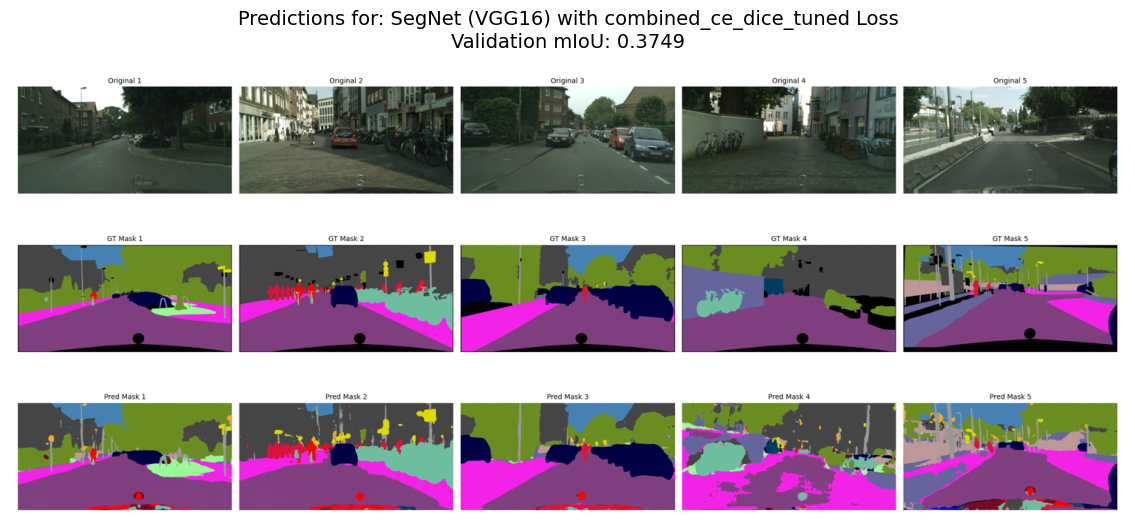


SegNet model visualization complete for Cityscapes.


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import os
import torch
import cv2
from PIL import Image

print("--- Starting Final Evaluation and Visualization for SegNet Models ---")

# Cityscapes Colormap for Visualization 
CITYSCAPES_VIS_COLORS = [
    (128, 64, 128),   # 0: road
    (244, 35, 232),   # 1: sidewalk
    (70, 70, 70),     # 2: building
    (102, 102, 156),  # 3: wall
    (190, 153, 153),  # 4: fence
    (153, 153, 153),  # 5: pole
    (250, 170, 30),   # 6: traffic light
    (220, 220, 0),    # 7: traffic sign
    (107, 142, 35),   # 8: vegetation
    (152, 251, 152),  # 9: terrain
    (70, 130, 180),   # 10: sky
    (220, 20, 60),    # 11: person
    (255, 0, 0),      # 12: rider
    (0, 0, 70),       # 13: car
    (0, 60, 100),     # 14: truck
    (0, 80, 100),     # 15: bus
    (0, 0, 230),      # 16: train
    (119, 11, 32),    # 17: motorcycle
    (110, 190, 160),  # 18: bicycle (using a distinct color for 18)
]
# Normalize colors to [0, 1] for matplotlib
norm_colors = [(r / 255., g / 255., b / 255.) for r, g, b in CITYSCAPES_VIS_COLORS]
cityscapes_cmap = ListedColormap(norm_colors[:NUM_CLASSES_CITYSCAPES]) 
# Set the color for the ignore_index (255) to black
cityscapes_cmap.set_bad(color=(0., 0., 0., 1.)) # Black for ignored pixels

# Select 5 fixed sample indices from the validation set once ---
NUM_SAMPLES_TO_PLOT = 5

eval_dataset_raw = CityscapesDataset(images_dir=VAL_IMAGE_DIR, masks_dir=VAL_MASK_DIR, transform=None)
fixed_sample_indices = np.random.choice(len(eval_dataset_raw), NUM_SAMPLES_TO_PLOT, replace=False)
print(f"Selected {NUM_SAMPLES_TO_PLOT} fixed sample indices for visualization: {fixed_sample_indices}")


def evaluate_and_plot_model(model_result_entry, sample_indices_to_use):
    dataset_name = model_result_entry['dataset']
    architecture = model_result_entry['architecture']
    encoder = model_result_entry['encoder']
    loss_function = model_result_entry['loss_function'] 
    model_path = model_result_entry['model_path']
    best_val_iou = model_result_entry['best_val_iou']
    status = model_result_entry['status']

    print(f"\n--- Visualizing Model: {architecture}-{encoder}-{loss_function} ---")

    if status != 'COMPLETED' or not os.path.exists(model_path):
        print(f"Skipping visualization for {architecture}-{encoder}-{loss_function} due to status: {status} or model not found.")
        return

    # Initialize the model architecture using the get_model function
    model = get_model(architecture, encoder, in_channels=3, num_classes=NUM_CLASSES_CITYSCAPES).to(DEVICE)

    print(f"Loading model from: {model_path}")
    try:
        model.load_state_dict(torch.load(model_path, map_location=DEVICE))
        model.eval() 
    except Exception as e:
        print(f"ERROR loading model {model_path}: {e}. Skipping visualization.")
        return

    # NUM_SAMPLES_TO_PLOT columns
    fig, axes = plt.subplots(3, NUM_SAMPLES_TO_PLOT, figsize=(NUM_SAMPLES_TO_PLOT * 4.5, 12))
    fig.suptitle(f"Predictions for: {architecture} ({encoder}) with {loss_function} Loss\nValidation mIoU: {best_val_iou:.4f}", fontsize=16, y=1.05)

    for i, idx in enumerate(sample_indices_to_use):
        # Unpack all three values returned by __getitem__
        original_image_np, original_mask_remapped_np, _ = eval_dataset_raw[idx] 

        # Apply cityscapes_val_transform for inference 
        input_image_tensor = cityscapes_val_transform(image=original_image_np)['image'].unsqueeze(0).to(DEVICE)
        
        with torch.no_grad():
            output_logits = model(input_image_tensor)
            predicted_mask = output_logits.argmax(dim=1).squeeze(0).cpu().numpy()

        axes[0, i].imshow(original_image_np)
        axes[0, i].set_title(f"Original {i+1}", fontsize=10)
        axes[0, i].axis('off')

        masked_gt_mask = np.ma.masked_where(original_mask_remapped_np == IGNORE_INDEX_CITYSCAPES, original_mask_remapped_np)
        axes[1, i].imshow(masked_gt_mask, cmap=cityscapes_cmap, vmin=0, vmax=NUM_CLASSES_CITYSCAPES-1)
        axes[1, i].set_title(f"GT Mask {i+1}", fontsize=10)
        axes[1, i].axis('off')

        masked_pred_mask = np.ma.masked_where(predicted_mask == IGNORE_INDEX_CITYSCAPES, predicted_mask)
        axes[2, i].imshow(masked_pred_mask, cmap=cityscapes_cmap, vmin=0, vmax=NUM_CLASSES_CITYSCAPES-1)
        axes[2, i].set_title(f"Pred Mask {i+1}", fontsize=10)
        axes[2, i].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()

#Run visualization for SegNet model from the training results ---
for result_entry in all_cityscapes_segnet_experiment_results: 
    # This is the correct function name
    evaluate_and_plot_model(result_entry, fixed_sample_indices)

print("\nSegNet model visualization complete for Cityscapes.")